In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import CXGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import trange

from gulps import logger
from gulps.comparisons.isa_library.fsim import fsim
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from gulps.viz.report_viz import report_benchmark_results

In [2]:
# --- ISA configuration ---
# Uncomment gates to include, or add your own.
_gates = [
    # CX family
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sq2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sq3cx"),
    (CXGate().power(1 / 8), 1 / 8, "sq8cx"),
    # iSwap family
    # (iSwapGate(), 1.0, "iswap"),
    # # (iSwapGate().power(1 / 2), 1 / 2, "sq2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sq3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sq4iswap"),
    # fSim family
    (fsim(np.pi / 2, np.pi / 6), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 4), 1 / 4, "sq4fsim"),
]
gate_set, costs, names = zip(*_gates)
isa = DiscreteISA(
    gate_set, costs, names, precompute_polytopes=False, max_sequence_length=12
)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    from gulps.core.coverage import coverage_report

    coverage_report(decomposer.isa.coverage_set)

In [3]:
logger.setLevel("INFO")
N = 1_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        result = decomposer(u)
        fid = average_gate_fidelity(u, Operator(result))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")
        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)
    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries:   0%|          | 0/1000 [00:00<?, ?it/s]

Decomposing random unitaries: 100%|██████████| 1000/1000 [00:07<00:00, 136.53it/s]


Benchmark: 1000/1000 successful (0 failures)
Fidelity: median=1.0000000000, min=0.9999999998
Avg time: 4.6 ms/decomposition
Cache: 73.3% hit rate (2740/3740)


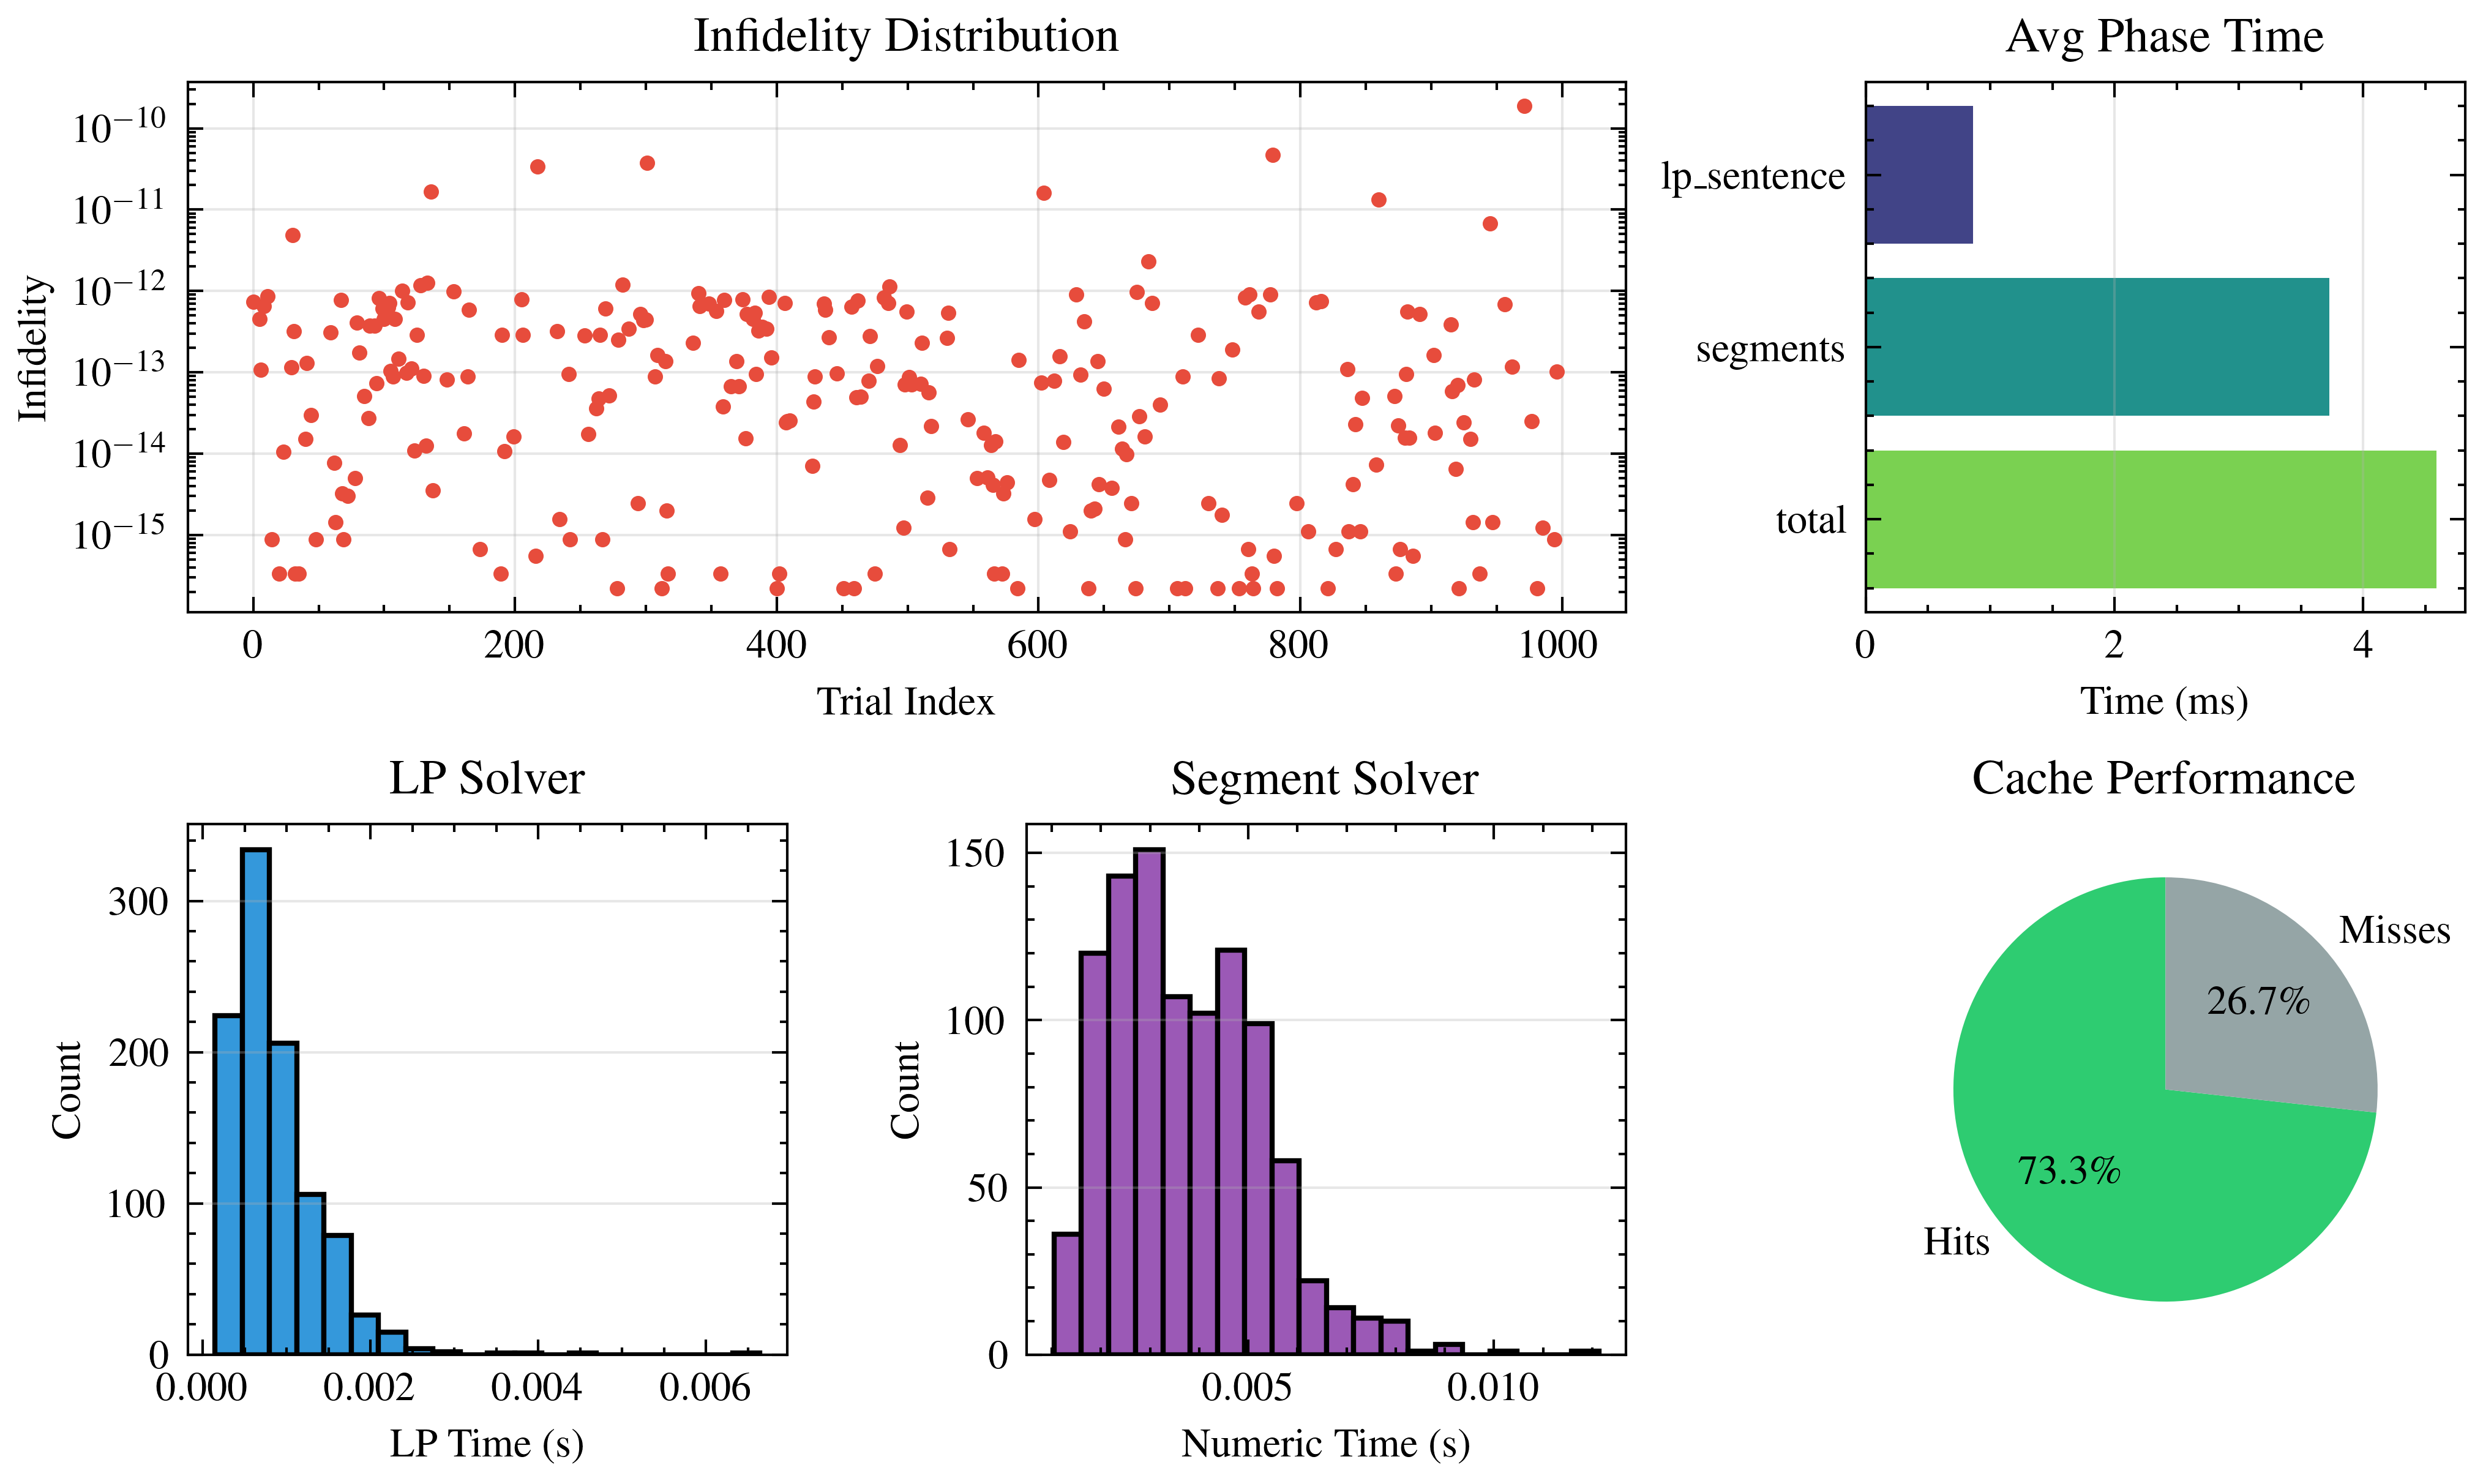

In [4]:
report_benchmark_results(fidelities, all_timings, decomposer, N, failures)

In [5]:
from qiskit.circuit.library import SwapGate

decomposer(SwapGate())

In [6]:
decomposer.last_timing

{'lp_sentence': 0.0032038879580795765,
 'segments': 0.005542371014598757,
 'total': 0.008746258972678334}

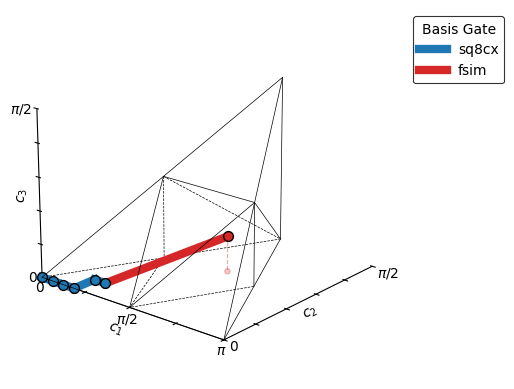

In [7]:
from IPython.display import display, clear_output
import time

for _ in range(20):
    clear_output(wait=True)
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa)
    display(fig)
    plt.close(fig)
    time.sleep(0.15)